In [1]:
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

In [15]:
IMG_SIZE = 128

def load_data(folder_path):
    data = []
    labels = []

    for category in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(folder_path, category)
        label = 0 if category == "NORMAL" else 1

        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                image = image.flatten()/ 255.0
                data.append(image)
                labels.append(label)
            except:
                pass

    return np.array(data), np.array(labels)

In [44]:
train_path=r"C:\\Users\\spiri\\Downloads\\Chest x-ray\\chest_xray\\test"
test_path=r"C:\\Users\\spiri\\Downloads\\Chest x-ray\\chest_xray\\train"

xtrain,ytrain=load_data(train_path)
xtest, ytest=load_data(test_path)

pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

sv_rbf=SVC(kernel="rbf")
sv_rbf.fit(pca_train,ytrain)

sv_linear=SVC(kernel="linear")
sv_linear.fit(pca_train,ytrain)

# Evaluate the default model
train_score_rbf = sv_rbf.score(pca_train, ytrain)
test_score_rbf = sv_rbf.score(pca_test, ytest)
print("Training Score of Rbf kernel:", train_score_rbf)
print("Testing Score of Rbf kernel:", test_score_rbf)

# Evaluate the Linear model
train_score_linear = sv_linear.score(pca_train, ytrain)
test_score_linear = sv_linear.score(pca_test, ytest)
print("Training Score of linear kernel:", train_score_linear)
print("Testing Score of linear kernel:", test_score_linear)



Training Score of Rbf kernel: 0.9791666666666666
Testing Score of Rbf kernel: 0.884010736196319
Training Score of linear kernel: 1.0
Testing Score of linear kernel: 0.8611963190184049


In [ ]:
def display_samples(folder, model, pca, category, num_samples=9):
    plt.figure(figsize=(12, 8))
    
    path = os.path.join(folder, category)
    files = os.listdir(path)[:num_samples]
    
    for i, file in enumerate(files):
        img_path = os.path.join(path, file)
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # Preprocessing
        img_flat = img_resized.flatten() / 255.0
        img_pca = pca.transform([img_flat])
        
        # Prediction
        pred = model.predict(img_pca)[0]
        pred_label = "PNEUMONIA" if pred == 1 else "NORMAL"
        
        plt.subplot(3, 3, i+1)
        plt.imshow(img_resized, cmap='gray')
        plt.title(f"Actual: {category}\nPred: {pred_label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

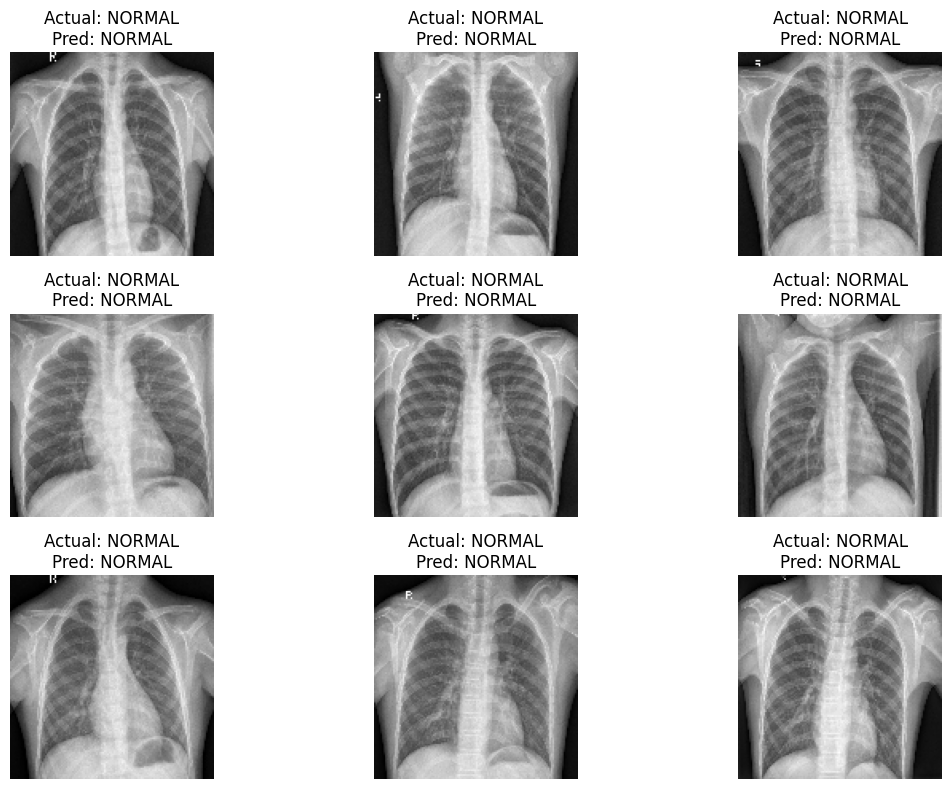

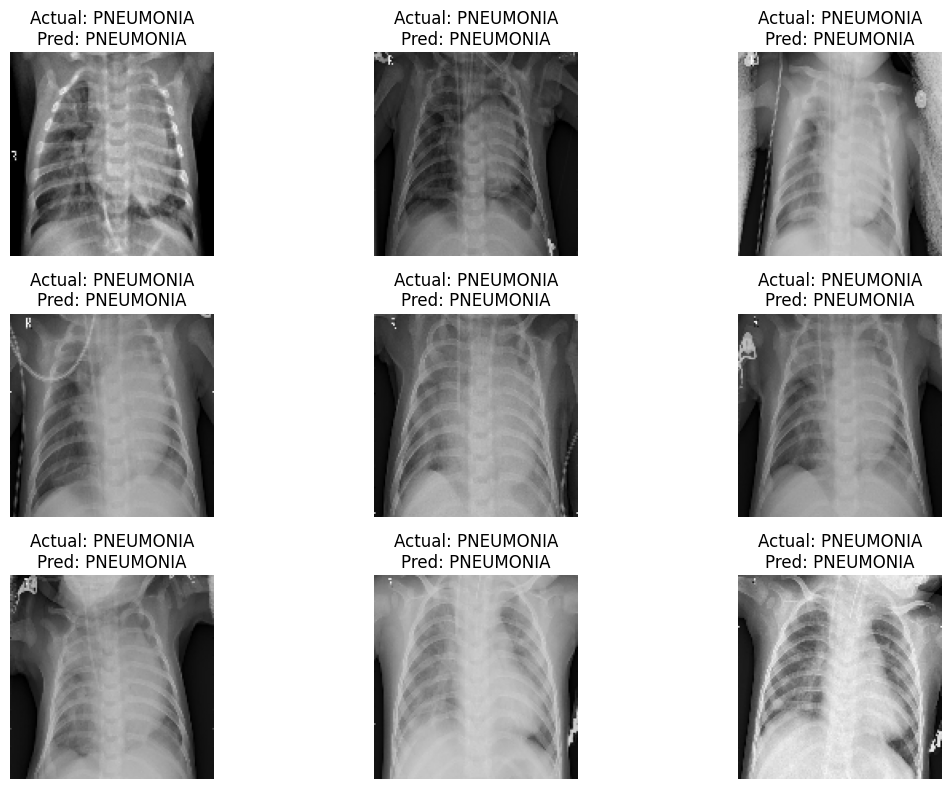

In [30]:
test_folder = "C:\\Users\\spiri\\Downloads\\Chest x-ray\\chest_xray\\test"

display_samples(test_folder, sv_rbf, pca, "NORMAL")
display_samples(test_folder, sv_rbf, pca,"PNEUMONIA")

In [45]:


xray_counts = {dec[label]: np.sum(ytrain == label) for label in dec.keys()}
table_data = {
    'Index': range(1, len(xray_counts) + 1),
    'X-ray Type': list(xray_counts.keys()),
    'Count': list(xray_counts.values())
}

chest_table = pd.DataFrame(table_data)
styled_table = chest_table.style.set_properties(
    **{'border': '3px solid black', 'text-align': 'center'}
)

print("\033[1mChest X-ray Counts:\033[0m")
display(styled_table)


Chest X-ray Counts:


,Index,X-ray Type,Count
0,1,Normal,234
1,2,Pneumonia,390


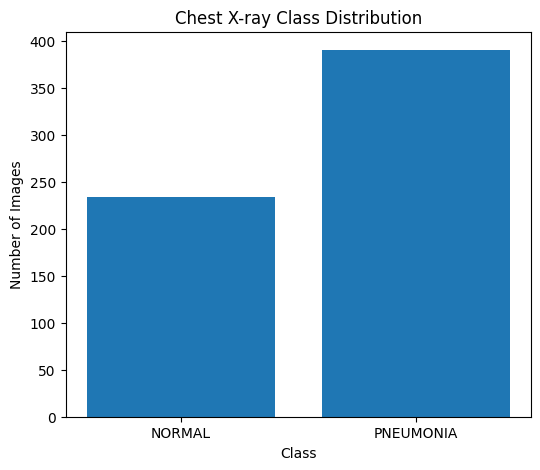

In [35]:


# Count values
counts = [np.sum(ytrain == 0), np.sum(ytrain == 1)]
labels = ["NORMAL", "PNEUMONIA"]

plt.figure(figsize=(6, 5))
plt.bar(labels, counts)

plt.title("Chest X-ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [40]:
from sklearn.utils import shuffle

# Shuffle once before loop
X_train_shuffled, y_train_shuffled = shuffle(xtrain, ytrain, random_state=42)

sizes = [0.2, 0.4, 0.6, 0.8]

rbf_acc = []
linear_acc = []

for s in sizes:
    n = int(len(X_train_shuffled) * s)
    
    X_sub = X_train_shuffled[:n]
    y_sub = y_train_shuffled[:n]
    
    # RBF
    model_rbf = SVC(kernel='rbf')
    model_rbf.fit(X_sub, y_sub)
    pred_rbf = model_rbf.predict(xtest)
    rbf_acc.append(accuracy_score(ytest, pred_rbf))
    print(f"accuracy score of rbf for {s*100}% of data is:",accuracy_score(ytest, pred_rbf))
    
    # Linear
    model_linear = SVC(kernel='linear')
    model_linear.fit(X_sub, y_sub)
    pred_linear = model_linear.predict(xtest)
    linear_acc.append(accuracy_score(ytest, pred_linear))
    print(f"accuracy score of linear for {s*100}% of data is:",accuracy_score(ytest, pred_linear))

accuracy score of rbf for 20.0% of data is: 0.8663726993865031
accuracy score of linear for 20.0% of data is: 0.84375
accuracy score of rbf for 40.0% of data is: 0.8880368098159509
accuracy score of linear for 40.0% of data is: 0.8759585889570553
accuracy score of rbf for 60.0% of data is: 0.8893788343558282
accuracy score of linear for 60.0% of data is: 0.88420245398773
accuracy score of rbf for 80.0% of data is: 0.8847776073619632
accuracy score of linear for 80.0% of data is: 0.8723159509202454


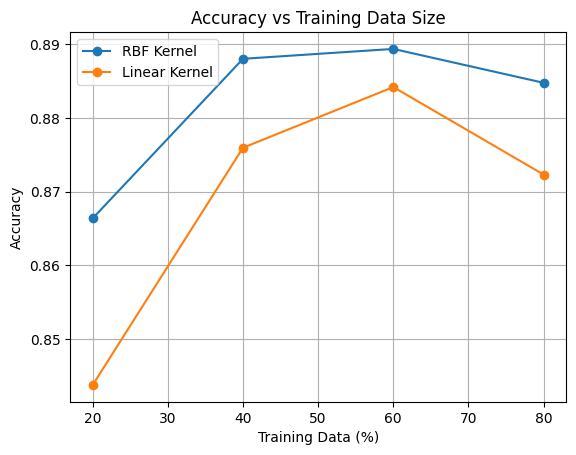

In [41]:
plt.plot([20, 40, 60, 80], rbf_acc, marker='o', label='RBF Kernel')
plt.plot([20, 40, 60, 80], linear_acc, marker='o', label='Linear Kernel')

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Data Size")
plt.legend()
plt.grid()

plt.show()

In [42]:
ypred = sv_rbf.predict(pca_test)

# Accuracy
accuracy = accuracy_score(ytest, ypred)

# F1 Score 
f1 = f1_score(ytest, ypred, average='weighted')

# Sensitivity 
sensitivity = recall_score(ytest, ypred, average='weighted')

# Confusion Matrix
cm = confusion_matrix(ytest, ypred)

specificity_list = []

for i in range(len(cm)):
    TP = cm[i][i]
    FN = sum(cm[i]) - TP
    FP = sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

#printing the results
print("Results for rbf kernel")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Results for rbf kernel
Accuracy: 0.884010736196319
F1 Score: 0.8859494591961391
Sensitivity (Recall): 0.884010736196319
Specificity: 0.8665874768468403


In [43]:
ypred = sv_linear.predict(pca_test)

# Accuracy
accuracy = accuracy_score(ytest, ypred)

# F1 Score 
f1 = f1_score(ytest, ypred, average='weighted')

# Sensitivity 
sensitivity = recall_score(ytest, ypred, average='weighted')

# Confusion Matrix
cm = confusion_matrix(ytest, ypred)

specificity_list = []

for i in range(len(cm)):
    TP = cm[i][i]
    FN = sum(cm[i]) - TP
    FP = sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)
    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

# Printing the results
print("Results for linear kernel")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

Results for linear kernel
Accuracy: 0.8611963190184049
F1 Score: 0.8647520444089948
Sensitivity (Recall): 0.8611963190184049
Specificity: 0.8483067523032883
